## Credit Card Customers

In [31]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

## Data Prepration

In [2]:
df = pd.read_csv("BankChurners.csv")
df.head(5)

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0.000093,0.99991
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0.000057,0.99994
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0.000021,0.99998
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0.000134,0.99987
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0.000022,0.99998


In [3]:
df1 = df.drop(columns=['Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1',
'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2']
)

In [4]:
df1.describe()

,CLIENTNUM,Customer_Age,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
count,1.012700e+04,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000
mean,7.391776e+08,46.325960,2.346203,35.928409,3.812580,2.341167,2.455317,8631.953698,1162.814061,7469.139637,0.759941,4404.086304,64.858695,0.712222,0.274894
std,3.690378e+07,8.016814,1.298908,7.986416,1.554408,1.010622,1.106225,9088.776650,814.987335,9090.685324,0.219207,3397.129254,23.472570,0.238086,0.275691
min,7.080821e+08,26.000000,0.000000,13.000000,1.000000,0.000000,0.000000,1438.300000,0.000000,3.000000,0.000000,510.000000,10.000000,0.000000,0.000000
25%,7.130368e+08,41.000000,1.000000,31.000000,3.000000,2.000000,2.000000,2555.000000,359.000000,1324.500000,0.631000,2155.500000,45.000000,0.582000,0.023000
50%,7.179264e+08,46.000000,2.000000,36.000000,4.000000,2.000000,2.000000,4549.000000,1276.000000,3474.000000,0.736000,3899.000000,67.000000,0.702000,0.176000
75%,7.731435e+08,52.000000,3.000000,40.000000,5.000000,3.000000,3.000000,11067.500000,1784.000000,9859.000000,0.859000,4741.000000,81.000000,0.818000,0.503000
max,8.283431e+08,73.000000,5.000000,56.000000,6.000000,6.000000,6.000000,34516.000000,2517.000000,34516.000000,3.397000,18484.000000,139.000000,3.714000,0.999000


In [5]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CLIENTNUM                 10127 non-null  int64  
 1   Attrition_Flag            10127 non-null  object 
 2   Customer_Age              10127 non-null  int64  
 3   Gender                    10127 non-null  object 
 4   Dependent_count           10127 non-null  int64  
 5   Education_Level           10127 non-null  object 
 6   Marital_Status            10127 non-null  object 
 7   Income_Category           10127 non-null  object 
 8   Card_Category             10127 non-null  object 
 9   Months_on_book            10127 non-null  int64  
 10  Total_Relationship_Count  10127 non-null  int64  
 11  Months_Inactive_12_mon    10127 non-null  int64  
 12  Contacts_Count_12_mon     10127 non-null  int64  
 13  Credit_Limit              10127 non-null  float64
 14  Total_

In [6]:
df1.isnull().sum()

CLIENTNUM                   0
Attrition_Flag              0
Customer_Age                0
Gender                      0
Dependent_count             0
Education_Level             0
Marital_Status              0
Income_Category             0
Card_Category               0
Months_on_book              0
Total_Relationship_Count    0
Months_Inactive_12_mon      0
Contacts_Count_12_mon       0
Credit_Limit                0
Total_Revolving_Bal         0
Avg_Open_To_Buy             0
Total_Amt_Chng_Q4_Q1        0
Total_Trans_Amt             0
Total_Trans_Ct              0
Total_Ct_Chng_Q4_Q1         0
Avg_Utilization_Ratio       0
dtype: int64

In [7]:
df1.dtypes

CLIENTNUM                     int64
Attrition_Flag               object
Customer_Age                  int64
Gender                       object
Dependent_count               int64
Education_Level              object
Marital_Status               object
Income_Category              object
Card_Category                object
Months_on_book                int64
Total_Relationship_Count      int64
Months_Inactive_12_mon        int64
Contacts_Count_12_mon         int64
Credit_Limit                float64
Total_Revolving_Bal           int64
Avg_Open_To_Buy             float64
Total_Amt_Chng_Q4_Q1        float64
Total_Trans_Amt               int64
Total_Trans_Ct                int64
Total_Ct_Chng_Q4_Q1         float64
Avg_Utilization_Ratio       float64
dtype: object

In [8]:
df['Credit_Limit'] = df['Credit_Limit'].round().astype(int)

In [9]:
print('\n=== UNKNOWN VALUES ===')
for col in df1.columns: 
  if df1[col].dtype == 'object': 
    count = (df1[col] == 'Unknown').sum() 
    if count: 
      print(f'{col}: {count}') 


=== UNKNOWN VALUES ===
Education_Level: 1519
Marital_Status: 749
Income_Category: 1112


In [10]:
Gender = df1.groupby('Gender')['CLIENTNUM'].count()
Gender

Gender
F    5358
M    4769
Name: CLIENTNUM, dtype: int64

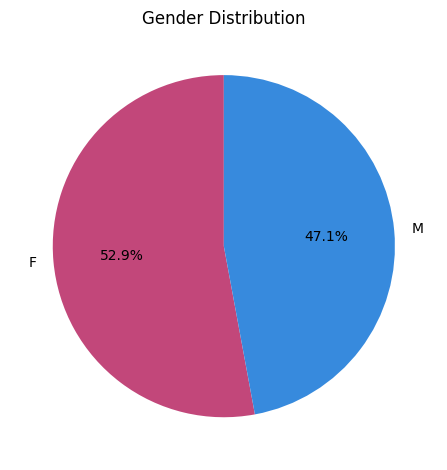

In [11]:
Gender.plot(
    kind='pie',
    autopct='%1.1f%%',
    colors=['#c2477a', '#378add'],
    title='Gender Distribution',
    ylabel='',
    startangle=90      
)

plt.tight_layout()
plt.show()

In [12]:
Existant_Customer = df1.groupby('Attrition_Flag')['CLIENTNUM'].count()
Existant_Customer

Attrition_Flag
Attrited Customer    1627
Existing Customer    8500
Name: CLIENTNUM, dtype: int64

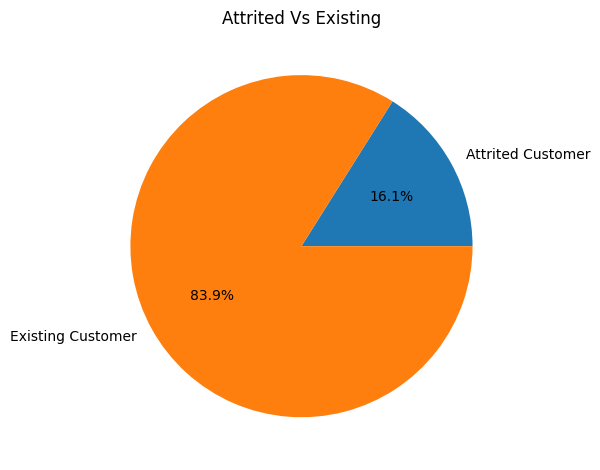

In [13]:
Existant_Customer.plot(
    kind='pie',
    autopct='%1.1f%%',          
    title='Attrited Vs Existing',
    xlabel='Count',
    ylabel='',
)

plt.tight_layout()
plt.show()

In [14]:
Education_Level = df1.groupby('Education_Level')['CLIENTNUM'].count()
Education_Level

Education_Level
College          1013
Doctorate         451
Graduate         3128
High School      2013
Post-Graduate     516
Uneducated       1487
Unknown          1519
Name: CLIENTNUM, dtype: int64

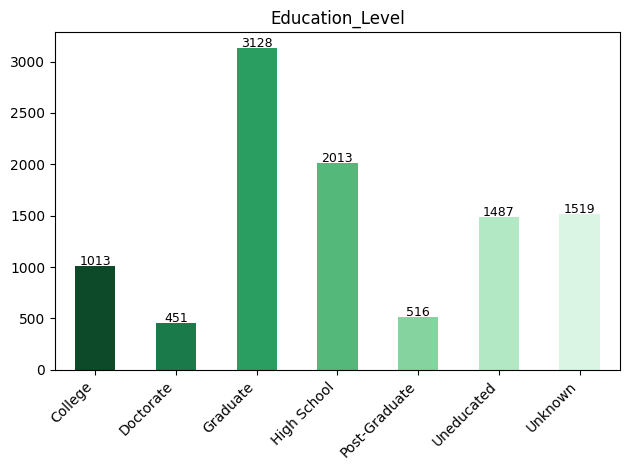

In [15]:
colors = ['#0d4a2a', '#1a7a4a', '#2a9e60', '#53b87a', '#85d4a0', '#b3e8c4', '#daf5e4']
Education_Level.plot(
    kind='bar',
    title='Education_Level',
    xlabel='',
    ylabel='',
    color=colors
)

plt.xticks(rotation=45, ha='right') 

for i, v in enumerate(Education_Level):
    plt.text(i, v + 10, str(v), ha='center', fontsize=9)  

plt.tight_layout()
plt.show()

In [16]:
Marital_Status = df1.groupby('Marital_Status')['CLIENTNUM'].count()
Marital_Status

Marital_Status
Divorced     748
Married     4687
Single      3943
Unknown      749
Name: CLIENTNUM, dtype: int64

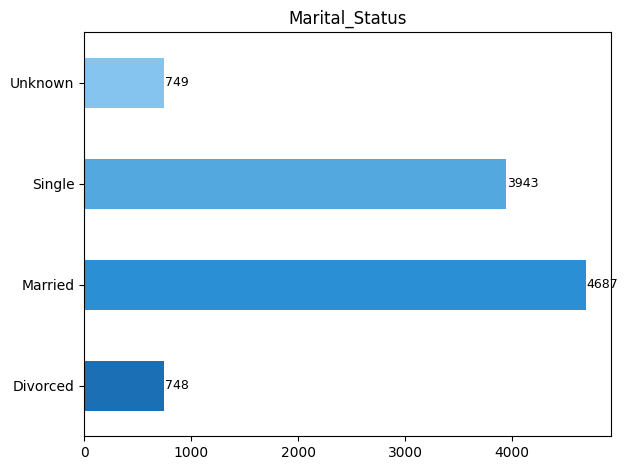

In [17]:
colors = ['#1a6fb5', '#2a8fd4', '#53a8e0', '#85c4ee']
Marital_Status.plot(
    kind='barh',         # horizontal
    title='Marital_Status',
    xlabel='',
    ylabel='',
    color=colors
)

for i, v in enumerate(Marital_Status):
    plt.text(v + 10, i, str(v), va='center', fontsize=9)  # va بدل ha عشان horizontal

plt.tight_layout()
plt.show()

In [18]:
Income_Category = df1.groupby('Income_Category')['CLIENTNUM'].count()
Income_Category

Income_Category
$120K +            727
$40K - $60K       1790
$60K - $80K       1402
$80K - $120K      1535
Less than $40K    3561
Unknown           1112
Name: CLIENTNUM, dtype: int64

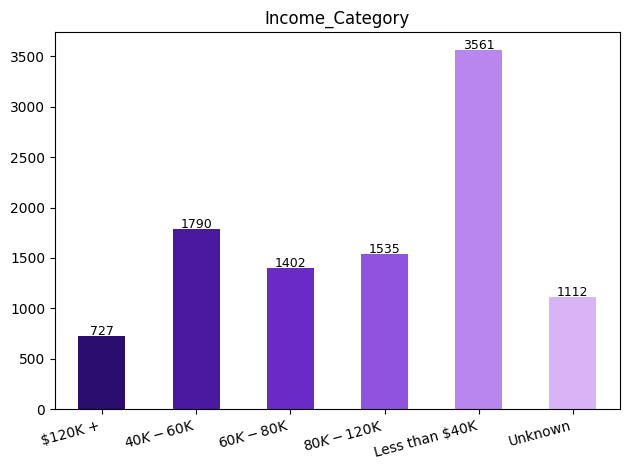

In [19]:
colors = ['#2a0d6e', '#4a1a9e', '#6a2ac8', '#8f53e0', '#b985ee', '#d8b3f5', '#eedaff']
Income_Category.plot(
    kind='bar',
    title='Income_Category',
    xlabel='',
    ylabel='',
    color=colors
)

plt.xticks(rotation=15, ha='right') 

for i, v in enumerate(Income_Category):
    plt.text(i, v + 10, str(v), ha='center', fontsize=9)  

plt.tight_layout()
plt.show()

In [20]:
Card_Category = df1.groupby('Card_Category')['CLIENTNUM'].count()
Card_Category

Card_Category
Blue        9436
Gold         116
Platinum      20
Silver       555
Name: CLIENTNUM, dtype: int64

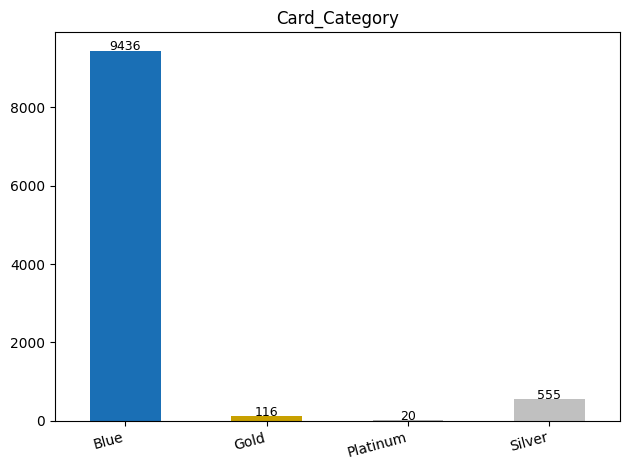

In [21]:
colors = ['#1a6fb5', '#c8a000', '#b0b0b0', '#c0c0c0']
Card_Category.plot(
    kind='bar',
    title='Card_Category',
    xlabel='',
    ylabel='',
    color=colors
)

plt.xticks(rotation=15, ha='right') 

for i, v in enumerate(Card_Category):
    plt.text(i, v + 10, str(v), ha='center', fontsize=9)  

plt.tight_layout()
plt.show()

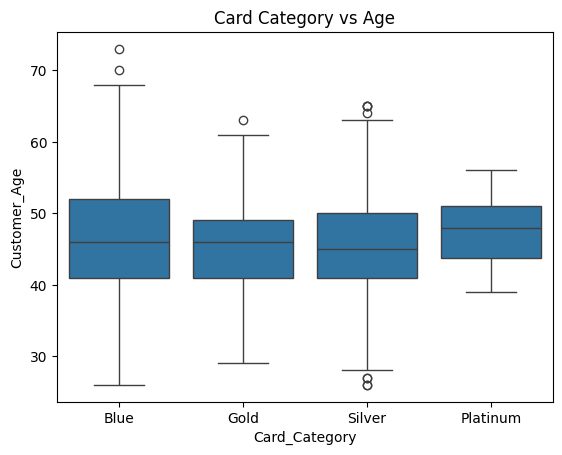

In [22]:

sns.boxplot(data=df, x='Card_Category', y='Customer_Age')
plt.title('Card Category vs Age')
plt.show()

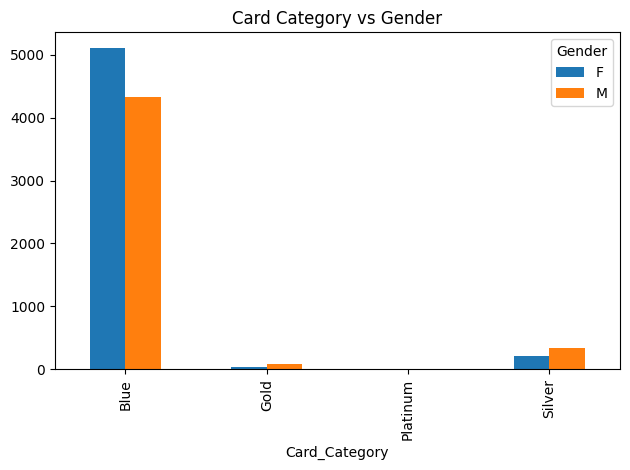

In [23]:
pd.crosstab(df['Card_Category'], df['Gender']).plot(kind='bar')
plt.title('Card Category vs Gender')
plt.tight_layout()
plt.show()

In [25]:
df_encoded = df1.copy()
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

for col in df_encoded.select_dtypes(include='object').columns:
    df_encoded[col] = le.fit_transform(df_encoded[col])

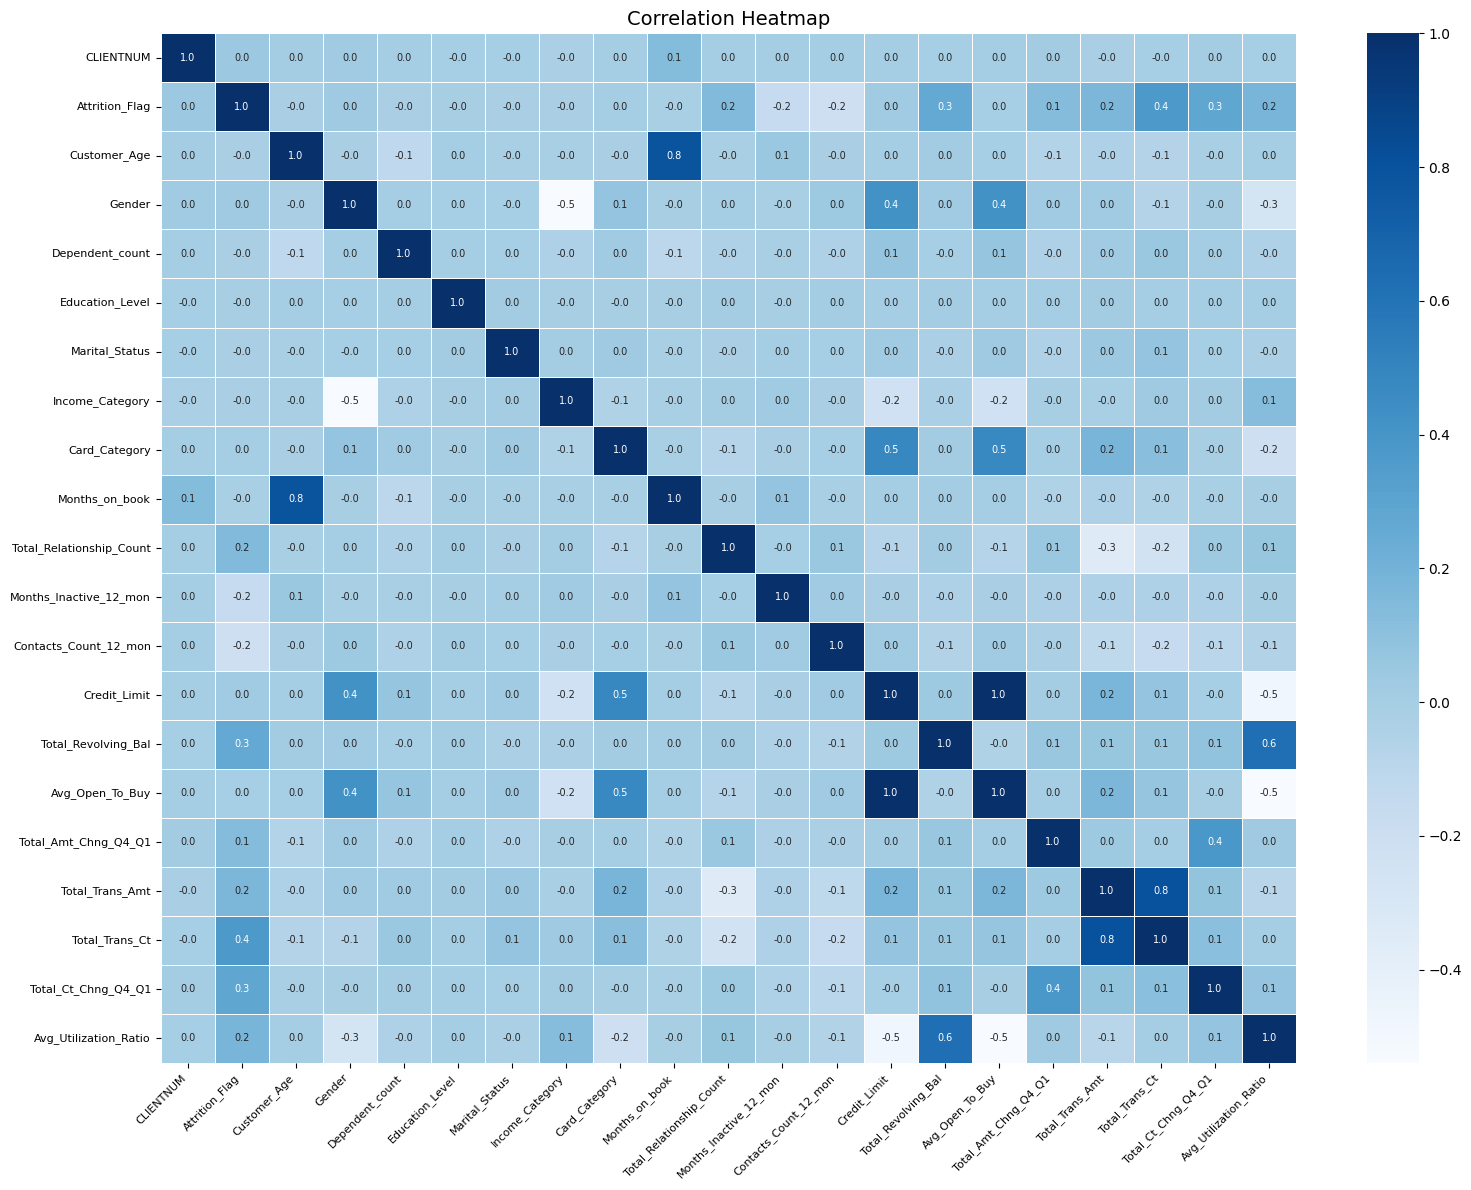

In [26]:
plt.figure(figsize=(16, 12))  
sns.heatmap(
    df_encoded.corr(), 
    annot=True, 
    fmt='.1f',         
    cmap='Blues',
    annot_kws={'size': 7},  
    linewidths=0.5,         
    linecolor='white'
)

plt.title('Correlation Heatmap', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

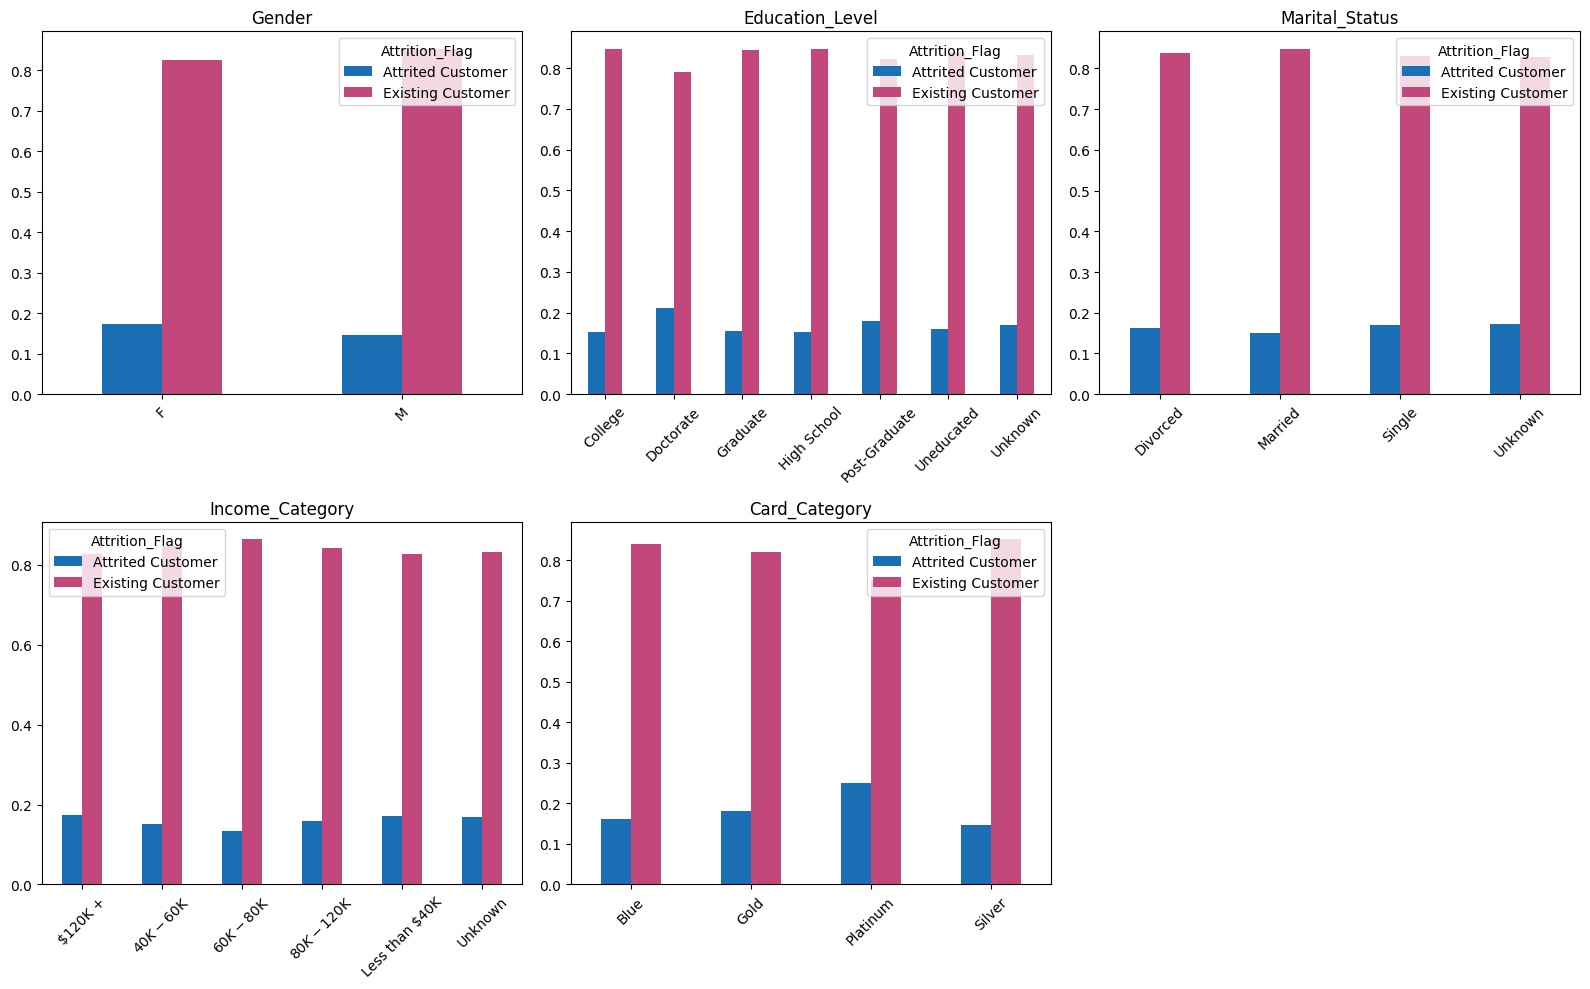

In [27]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

cat_cols = ['Gender', 'Education_Level', 'Marital_Status', 
            'Income_Category', 'Card_Category']

for ax, col in zip(axes.flatten(), cat_cols):
    pd.crosstab(df[col], df['Attrition_Flag'], normalize='index').plot(
        kind='bar',
        ax=ax,
        color=['#1a6fb5', '#c2477a']
    )
    ax.set_title(col)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)

axes[-1, -1].set_visible(False)
plt.tight_layout()
plt.show()

## Bilding ML Algorithem --Binary Classification

In [32]:
from sklearn.preprocessing import LabelEncoder

df_model = df1.copy()

le = LabelEncoder()
for col in df_model.select_dtypes(include='object').columns:
    df_model[col] = le.fit_transform(df_model[col])

X = df_model.drop(['Attrition_Flag', 'CLIENTNUM'], axis=1)
y = df_model['Attrition_Flag']

In [ ]:

X_simple = df_model[['Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Revolving_Bal']]

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_simple, y, test_size=0.2, random_state=42
)

model_simple = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight='balanced',
    random_state=42
)
model_simple.fit(X_train_s, y_train_s)

y_pred_s = model_simple.predict(X_test_s)
print(classification_report(y_test_s, y_pred_s))

              precision    recall  f1-score   support

           0       0.72      0.85      0.78       327
           1       0.97      0.94      0.95      1699

    accuracy                           0.92      2026
   macro avg       0.85      0.89      0.87      2026
weighted avg       0.93      0.92      0.93      2026



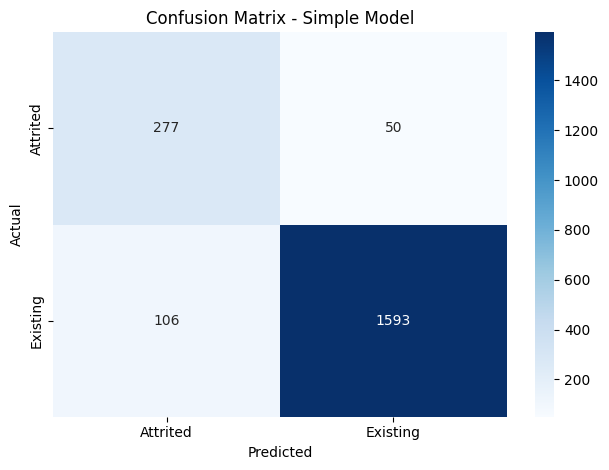

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test_s, y_pred_s)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Attrited', 'Existing'],
            yticklabels=['Attrited', 'Existing'])

plt.title('Confusion Matrix - Simple Model')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

In [34]:
import joblib
joblib.dump(model_simple, 'model_simple.pkl')

['model_simple.pkl']

In [41]:
print(df1['Total_Trans_Amt'].min())
print(df1['Total_Trans_Amt'].max())
print(df1['Total_Trans_Ct'].min())
print(df1['Total_Trans_Ct'].max())
print(df1['Total_Revolving_Bal'].min())
print(df1['Total_Revolving_Bal'].max())

510
18484
10
139
0
2517


In [42]:
import joblib
joblib.dump(model_simple, 'model_simple.pkl')

['model_simple.pkl']